In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve

import pickle

In [26]:
# 2. LOAD DATA

df = pd.read_csv("employee_burnout.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.head()



,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [27]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [29]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [31]:
df.isnull().sum()

,0
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0


In [32]:
# 3. DATA CLEANING

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)




In [7]:
# 4. CREATE TARGET COLUMN

# Convert burnout_risk → Burnout_Category

le_target = LabelEncoder()
df['Burnout_Category'] = le_target.fit_transform(df['burnout_risk'])

In [8]:
# 5. ENCODE OTHER COLUMNS

le = LabelEncoder()

if 'day_type' in df.columns:
    df['day_type'] = le.fit_transform(df['day_type'])


In [9]:
# 6. DROP UNUSED COLUMNS

if 'user_id' in df.columns:
    df.drop('user_id', axis=1, inplace=True)

# OPTIONAL (better accuracy)
df.drop('burnout_risk', axis=1, inplace=True)

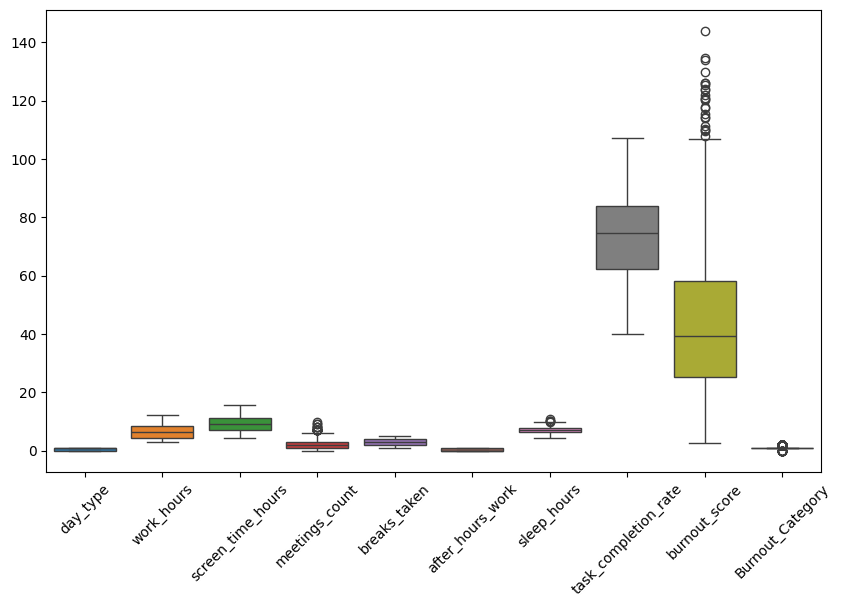

In [10]:
# 7. VISUALIZATION

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.savefig("figure7_boxplot.png")
plt.show()





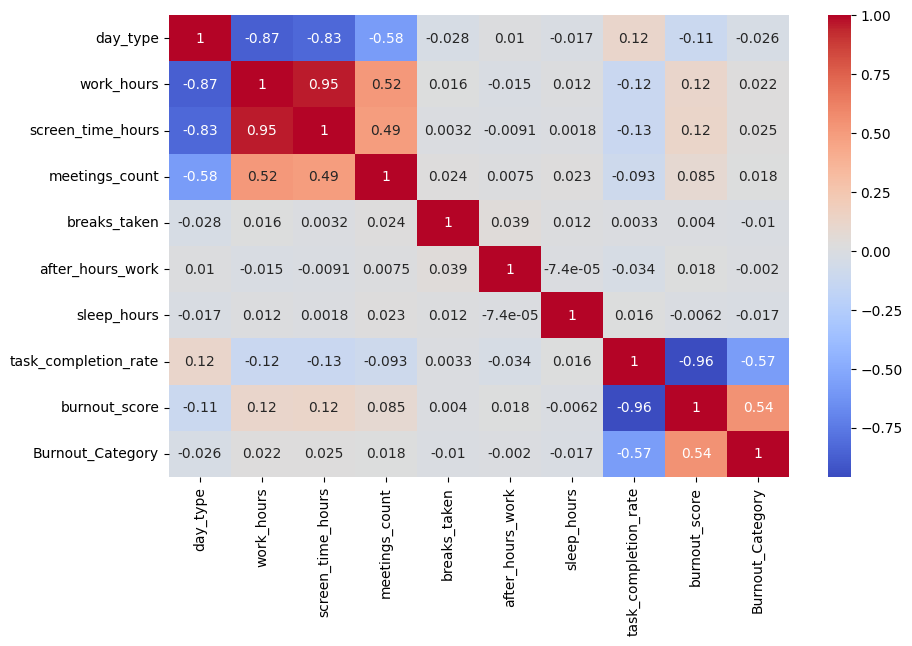

In [11]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.savefig("figure8_heatmap.png")
plt.show()

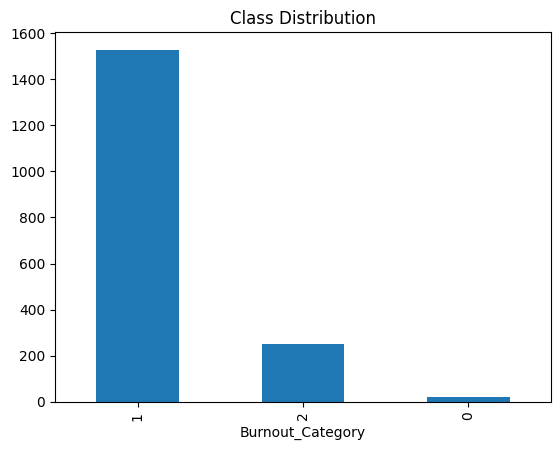

In [12]:
# Class Distribution
df['Burnout_Category'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.savefig("figure11_distribution.png")
plt.show()

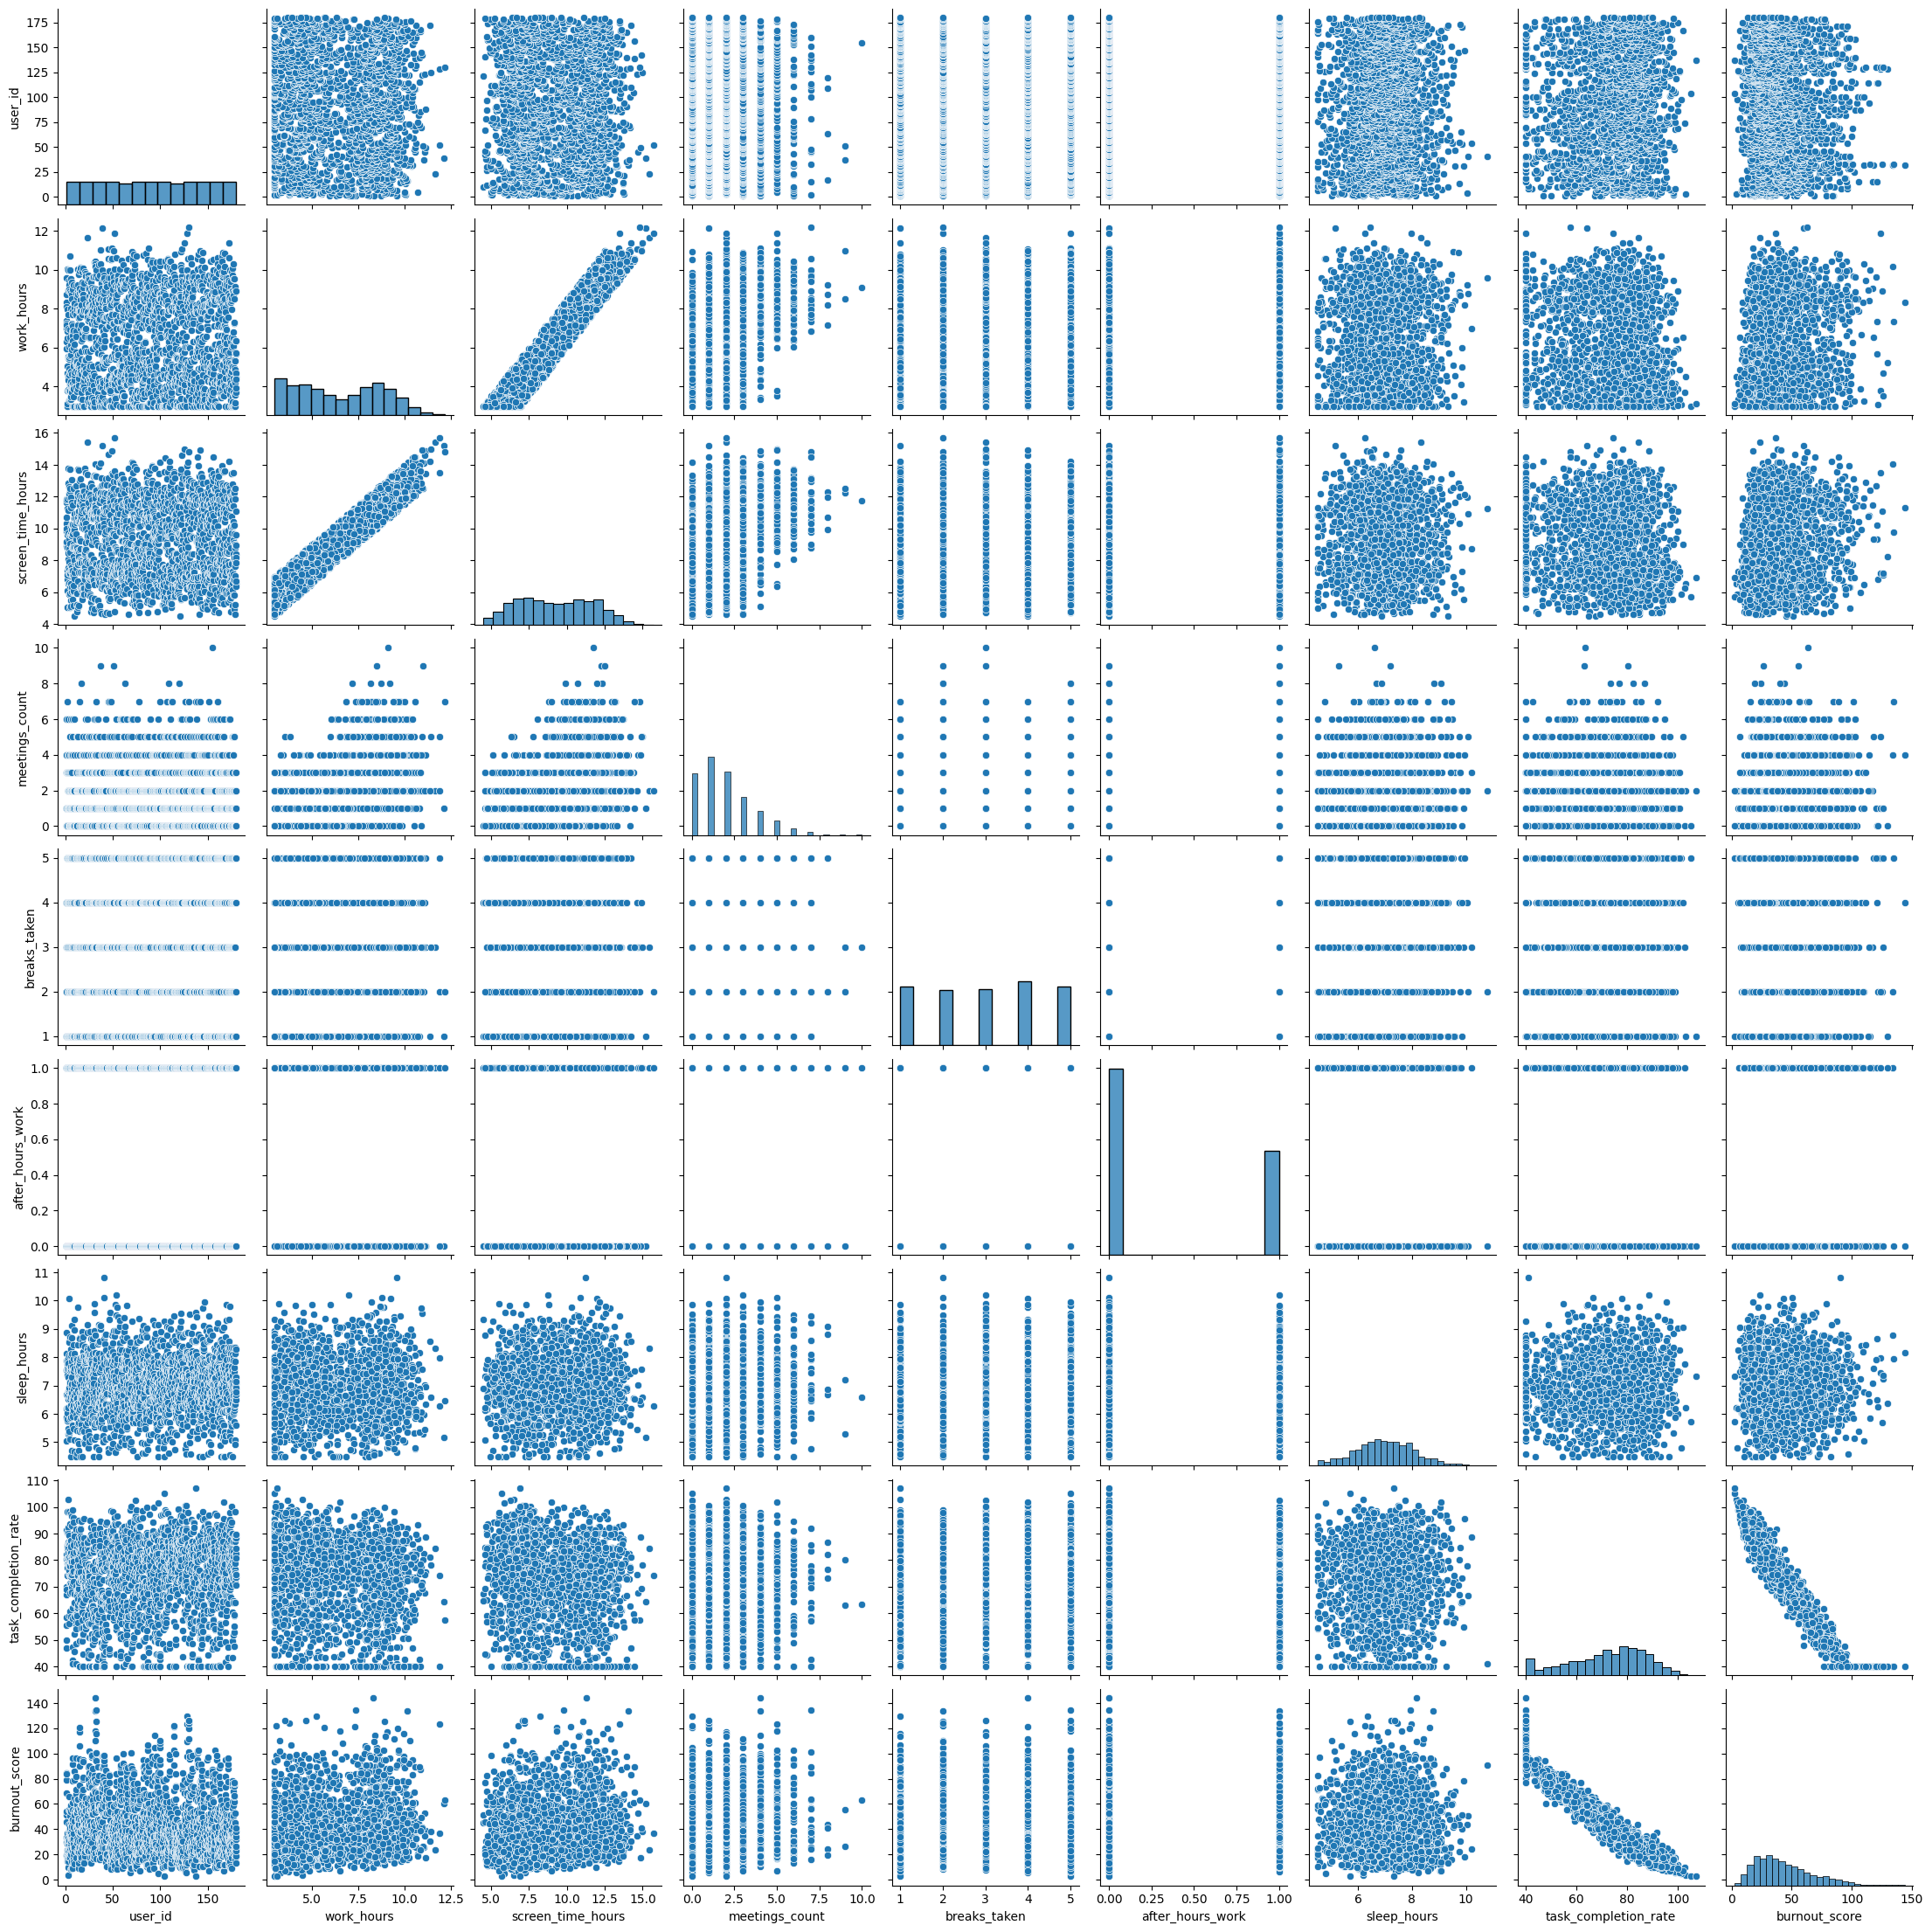

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: reduce columns for cleaner plot
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Pairplot
sns.pairplot(numeric_df)

# Save figure
plt.savefig("figure9_pairplot.png")

# Show plot
plt.show()

In [13]:
# 8. FEATURES & TARGET

X = df.drop('Burnout_Category', axis=1)
y = df['Burnout_Category']


In [14]:
# 9. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
# 10. SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [17]:
# 11. LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))



LR Accuracy: 0.9916666666666667
[[  1   0   1]
 [  0 305   0]
 [  0   2  51]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.99      1.00      1.00       305
           2       0.98      0.96      0.97        53

    accuracy                           0.99       360
   macro avg       0.99      0.82      0.88       360
weighted avg       0.99      0.99      0.99       360



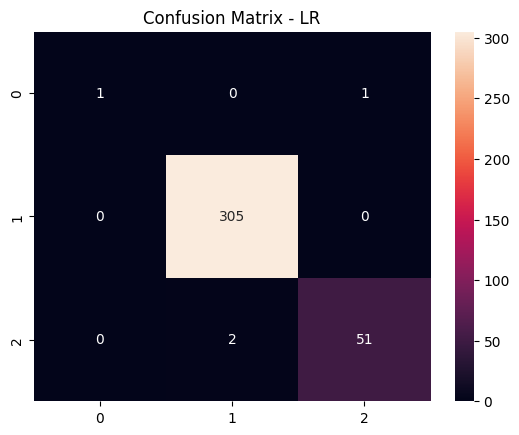

In [18]:
# Confusion Matrix LR
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LR")
plt.savefig("figure15_confusion_lr.png")
plt.show()

RF Accuracy: 0.9972222222222222


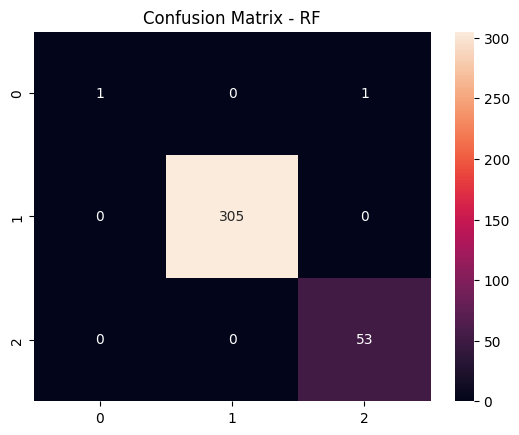

In [19]:
# 12. RANDOM FOREST

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - RF")
plt.savefig("figure17_confusion_rf.png")
plt.show()

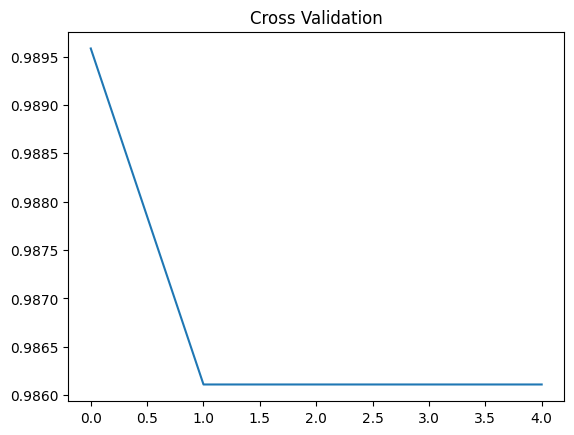

In [20]:
# 13. CROSS VALIDATION

scores = cross_val_score(lr, X_train, y_train, cv=5)

plt.plot(scores)
plt.title("Cross Validation")
plt.savefig("figure21_cv.png")
plt.show()

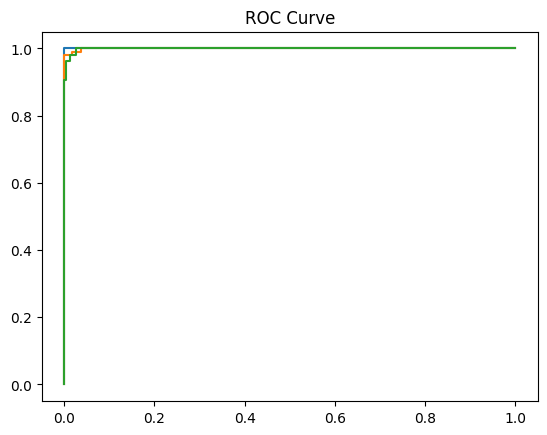

In [21]:
# 14. ROC CURVE

y_test_bin = label_binarize(y_test, classes=np.unique(y))

y_score = lr.predict_proba(X_test)

for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr)

plt.title("ROC Curve")
plt.savefig("figure22_roc.png")
plt.show()

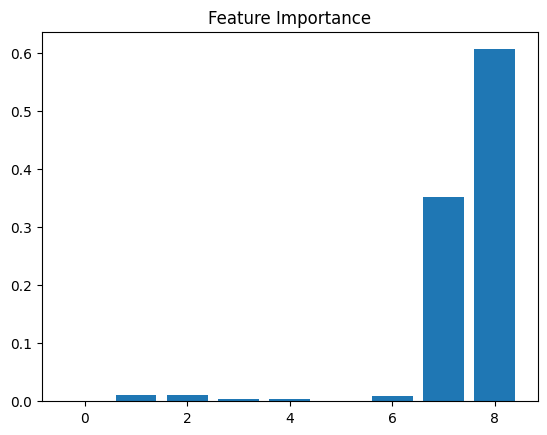

In [22]:
# 15. FEATURE IMPORTANCE

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.savefig("figure23_importance.png")
plt.show()

In [24]:
# 16. SAVE MODEL

pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))


print(" ALL DONE SUCCESSFULLY")

 ALL DONE SUCCESSFULLY
